<a href="https://colab.research.google.com/github/tarachandkadyan2-hub/ipc-crimes-analysis/blob/main/IPC_Crimes_Week2_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# State/UT-wise IPC Crimes (2020–2022) — Week 2 EDA
## Exploratory Data Analysis and Visualization
This notebook performs EDA on the NCRB State/UT-wise IPC Crimes dataset for 2020–2022. It covers descriptive statistics, data-quality checks, outlier inspection, aggregation, trends, rankings, and visualizations.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)


In [8]:
# Load the cleaned dataset included in this project
df = pd.read_csv('/NCRB_Table_1A.1.csv')
year_cols = ['2020','2021','2022']
df.head()

,Sl. No.,State/UT,2020,2021,2022,Mid-Year Projected Population (in Lakhs) (2022),Rate of Cognizable Crimes (IPC) (2022),Chargesheeting Rate (2022)
0,1,Andhra Pradesh,188997,179611,158547,530.3,299.0,86.5
1,2,Arunachal Pradesh,2244,2626,2308,15.5,148.8,47.2
2,3,Assam,111558,119883,59315,354.9,167.1,32.6
3,4,Bihar,194698,186006,211079,1255.3,168.1,75.4
4,5,Chhattisgarh,65216,70519,73822,299.5,246.5,80.4


In [6]:
import os
print(os.listdir())

['.config', 'sample_data']


## 1. Dataset Overview


In [9]:
print('Shape:', df.shape)
print('\nData types:')
print(df.dtypes)
print('\nDescriptive statistics:')
display(df[year_cols].describe().T)


Shape: (36, 8)

Data types:
Sl. No.                                              int64
State/UT                                            object
2020                                                 int64
2021                                                 int64
2022                                                 int64
Mid-Year Projected Population (in Lakhs) (2022)    float64
Rate of Cognizable Crimes (IPC) (2022)             float64
Chargesheeting Rate (2022)                         float64
dtype: object

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
2020,36.0,118176.555556,176923.509449,107.0,2524.50,50451.5,165794.25,891700.0
2021,36.0,101760.000000,118652.699382,89.0,2479.75,47069.0,163026.25,367218.0
2022,36.0,98927.194444,117142.926576,64.0,2934.25,46232.0,157014.00,401787.0


## 2. Data Quality Checks


In [10]:
print('Missing values:')
print(df.isna().sum())
print('\nDuplicate rows:', df.duplicated().sum())
print('\nNumber of State/UT rows:', df['State/UT'].nunique())


Missing values:
Sl. No.                                            0
State/UT                                           0
2020                                               0
2021                                               0
2022                                               0
Mid-Year Projected Population (in Lakhs) (2022)    0
Rate of Cognizable Crimes (IPC) (2022)             0
Chargesheeting Rate (2022)                         0
dtype: int64

Duplicate rows: 0

Number of State/UT rows: 36


In [11]:
for col in year_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df['State/UT'] = df['State/UT'].astype(str).str.strip()
print('Numeric columns confirmed:', df[year_cols].dtypes.tolist())


Numeric columns confirmed: [dtype('int64'), dtype('int64'), dtype('int64')]


## 3. Outlier Inspection
IPC counts are highly dispersed across states/UTs. Boxplots help identify unusually high observations. These observations are not automatically errors; they may reflect population size, reporting patterns, or genuine differences in registered cases.


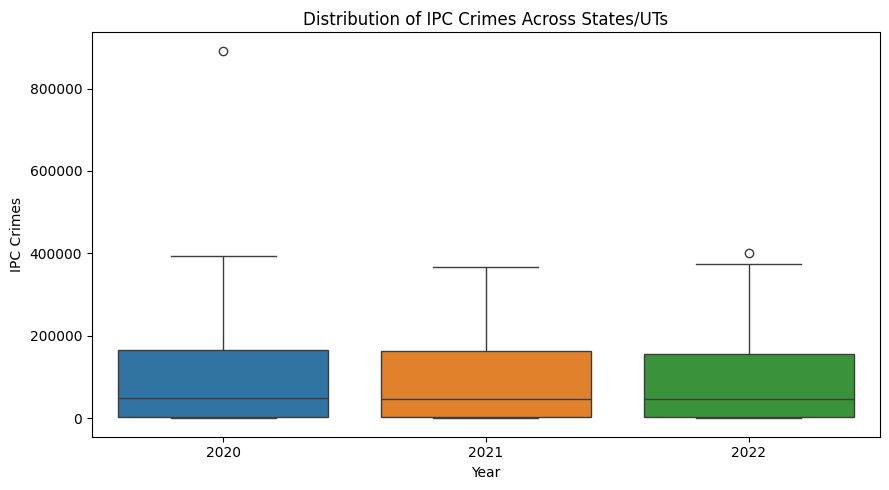

In [12]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df[year_cols])
plt.title('Distribution of IPC Crimes Across States/UTs')
plt.xlabel('Year')
plt.ylabel('IPC Crimes')
plt.tight_layout()
plt.show()


## 4. National Year-over-Year Trend


,Total IPC Crimes
2020,4254356
2021,3663360
2022,3561379


Change from 2020 to 2022: -16.29%


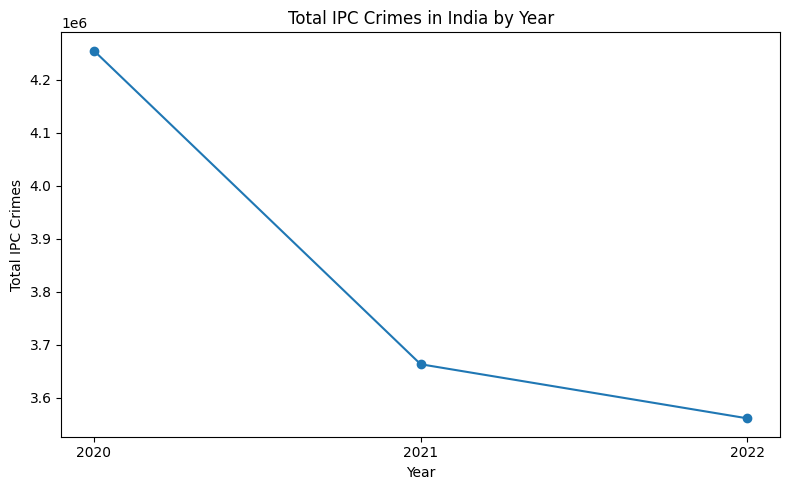

In [13]:
yearly_total = df[year_cols].sum()
display(yearly_total.to_frame('Total IPC Crimes'))
pct_change_20_22 = (yearly_total['2022'] - yearly_total['2020']) / yearly_total['2020'] * 100
print(f'Change from 2020 to 2022: {pct_change_20_22:.2f}%')

plt.figure(figsize=(8,5))
plt.plot(yearly_total.index, yearly_total.values, marker='o')
plt.title('Total IPC Crimes in India by Year')
plt.xlabel('Year')
plt.ylabel('Total IPC Crimes')
plt.tight_layout()
plt.show()


## 5. Top 10 States/UTs by Combined IPC Crimes


,State/UT,Total_2020_2022
22,Tamil Nadu,1408465
13,Maharashtra,1135273
25,Uttar Pradesh,1114802
12,Madhya Pradesh,886525
31,Delhi,841525
6,Gujarat,789505
20,Rajasthan,643921
3,Bihar,591783
11,Kerala,527600
0,Andhra Pradesh,527155


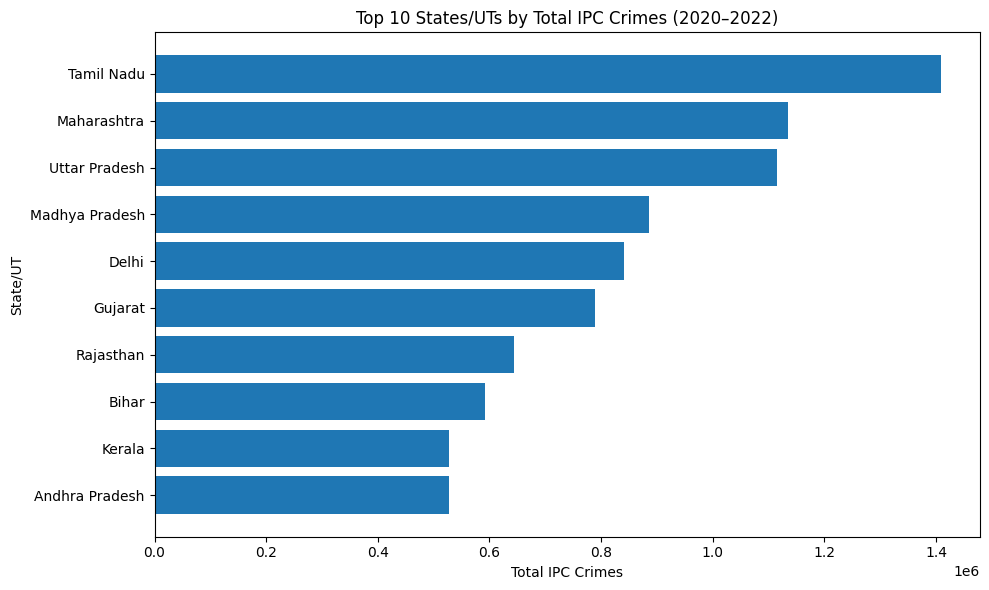

In [14]:
df['Total_2020_2022'] = df[year_cols].sum(axis=1)
top10 = df.nlargest(10, 'Total_2020_2022')[['State/UT','Total_2020_2022']]
display(top10)

plt.figure(figsize=(10,6))
plt.barh(top10['State/UT'][::-1], top10['Total_2020_2022'][::-1])
plt.title('Top 10 States/UTs by Total IPC Crimes (2020–2022)')
plt.xlabel('Total IPC Crimes')
plt.ylabel('State/UT')
plt.tight_layout()
plt.show()


## 6. State-Level Trend Example: Maharashtra


,State/UT,Year,IPC_Crimes
13,Maharashtra,2020,394017
49,Maharashtra,2021,367218
85,Maharashtra,2022,374038


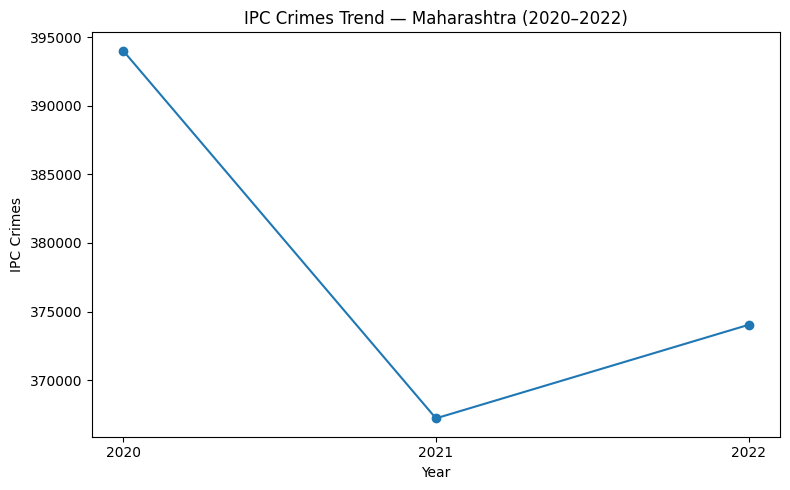

In [15]:
long_df = df.melt(id_vars=['State/UT'], value_vars=year_cols, var_name='Year', value_name='IPC_Crimes')
long_df['Year'] = long_df['Year'].astype(int)
state_name = 'Maharashtra'
state_data = long_df[long_df['State/UT'] == state_name]
display(state_data)

plt.figure(figsize=(8,5))
plt.plot(state_data['Year'], state_data['IPC_Crimes'], marker='o')
plt.title(f'IPC Crimes Trend — {state_name} (2020–2022)')
plt.xlabel('Year')
plt.ylabel('IPC Crimes')
plt.xticks([2020,2021,2022])
plt.tight_layout()
plt.show()


## 7. Additional Insights


In [16]:
df['Change_2020_2022'] = df['2022'] - df['2020']
print('Top 5 states/UTs in 2022:')
display(df.nlargest(5, '2022')[['State/UT','2022']])
print('Largest increases from 2020 to 2022:')
display(df.nlargest(5, 'Change_2020_2022')[['State/UT','Change_2020_2022']])
print('Largest declines from 2020 to 2022:')
display(df.nsmallest(5, 'Change_2020_2022')[['State/UT','Change_2020_2022']])


Top 5 states/UTs in 2022:


,State/UT,2022
25,Uttar Pradesh,401787
13,Maharashtra,374038
31,Delhi,300429
12,Madhya Pradesh,298578
20,Rajasthan,236090


Largest increases from 2020 to 2022:


,State/UT,Change_2020_2022
11,Kerala,86759
31,Delhi,51237
25,Uttar Pradesh,46677
20,Rajasthan,42811
18,Odisha,34881


Largest declines from 2020 to 2022:


,State/UT,Change_2020_2022
22,Tamil Nadu,-697787
6,Gujarat,-247249
2,Assam,-52243
0,Andhra Pradesh,-30450
13,Maharashtra,-19979


## 8. Interpretation and Limitations
- The total number of registered IPC crimes in the dataset falls from 4,254,356 in 2020 to 3,561,379 in 2022.
- Tamil Nadu has the highest combined 2020–2022 count, while Uttar Pradesh has the highest 2022 count.
- Large differences between states should not be interpreted as risk or prevalence by themselves because the dataset contains raw registered-crime counts and states differ in population and reporting patterns.
- The NCRB source itself cautions that States/UTs should not be compared purely on crime figures.
